<a href="https://colab.research.google.com/github/Raedaloauni/Projet_DL/blob/main/Prediction_de_direction_du_marche_financier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. INSTALLATION ET IMPORTATION DES BIBLIOTHÈQUES


In [1]:
print("--- [1/6] Installation des packages ---")
!pip install yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, LSTM, Dropout, BatchNormalization, Input, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping

# Configuration des graphiques
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_theme(style="white")

print("TensorFlow Version:", tf.__version__)

--- [1/6] Installation des packages ---
TensorFlow Version: 2.20.0


#2. PIPELINE DE PRÉTRAITEMENT DES DONNÉES (DATA PIPELINE)

In [2]:
print("\n--- [2/6] Téléchargement et Prétraitement des données ---")
ticker = "BTC-USD"
data = yf.download(ticker, start="2020-01-01", end="2026-01-01")

# SOLUTION ANTI-BIAIS : Transformer les prix bruts en rendements (variations en %)
data['Returns'] = data['Close'].pct_change()

# Ajout d'un indicateur de tendance (RSI basique pour donner du contexte à l'IA)
delta = data['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / (loss + 1e-10)
data['RSI'] = 100 - (100 / (1 + rs))

# Nettoyage des lignes vides créées par les calculs de moyennes mobiles
data.dropna(inplace=True)

# Création de la cible (Target) : 1 si le prix monte demain, 0 s'il baisse
data['Target'] = (data['Close'].shift(-1) > data['Close']).astype(int)

# Sélection des fonctionnalités épurées et normalisées
features = ['Returns', 'RSI', 'Volume']
df_features = data[features].values
df_target = data['Target'].values

# Séparation chronologique : 80% Entraînement / 20% Test (Pas de shuffle aléatoire !)
train_size = int(len(df_features) * 0.8)
train_data = df_features[:train_size]
test_data = df_features[train_size:]

train_target = df_target[:train_size]
test_target = df_target[train_size:]

# Normalisation entre 0 et 1 (Essentiel pour stabiliser les gradients)
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

# Fonction pour découper en fenêtres temporelles (Ici, séquences de 30 jours)
def create_sequences(data, targets, sequence_length=30):
    X, y = [], []
    for i in range(sequence_length, len(data) - 1):
        X.append(data[i-sequence_length:i])
        y.append(targets[i])
    return np.array(X), np.array(y)

SEQUENCE_LENGTH = 30
X_train, y_train = create_sequences(train_scaled, train_target, SEQUENCE_LENGTH)
X_test, y_test = create_sequences(test_scaled, test_target, SEQUENCE_LENGTH)

print(f"Forme finale de X_train : {X_train.shape} (Échantillons, Jours, Features)")


--- [2/6] Téléchargement et Prétraitement des données ---


/tmp/ipykernel_7017/1495560021.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2020-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed

Forme finale de X_train : (1712, 30, 3) (Échantillons, Jours, Features)


# 3. CONSTRUCTIONS DES ARCHITECTURES DL

In [3]:
print("\n--- [3/6] Initialisation des architectures (LSTM & Transformer) ---")
input_shape = (X_train.shape[1], X_train.shape[2])

# --- Modèle 1 : LSTM profond ---
model_lstm = Sequential([
    LSTM(units=64, return_sequences=True, input_shape=input_shape),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(units=32, return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),
    Dense(units=16, activation='relu'),
    Dense(units=1, activation='sigmoid')
], name="LSTM_Finance")

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --- Modèle 2 : Transformer moderne ---
def build_transformer(input_shape):
    inputs = Input(shape=input_shape)

    # Couche clé demandée par le professeur : Le Multi-Head Attention
    attention_out = MultiHeadAttention(num_heads=4, key_dim=input_shape[1])(inputs, inputs)
    attention_out = Dropout(0.3)(attention_out)

    # Connexion résiduelle et normalisation
    x = LayerNormalization(epsilon=1e-6)(inputs + attention_out)

    x = Dense(units=16, activation='relu')(x)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.3)(x)

    outputs = Dense(units=1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs, name="Transformer_Finance")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_transformer = build_transformer(input_shape)


--- [3/6] Initialisation des architectures (LSTM & Transformer) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# 4. ENTRAÎNEMENT DES MODÈLES ET CONFIGURATION DE L'EARLY STOPPING


In [4]:
print("\n--- [4/6] Entraînement des modèles (Veuillez patienter...) ---")

# Sécurité anti-overfitting exigée au barème
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Entraînement du LSTM
print("\n-> Entraînement du LSTM en cours...")
history_lstm = model_lstm.fit(
    X_train, y_train, epochs=40, batch_size=32, validation_split=0.1, callbacks=[early_stopping], verbose=1
)

# Entraînement du Transformer
print("\n-> Entraînement du Transformer en cours...")
history_transformer = model_transformer.fit(
    X_train, y_train, epochs=40, batch_size=32, validation_split=0.1, callbacks=[early_stopping], verbose=1
)


--- [4/6] Entraînement des modèles (Veuillez patienter...) ---

-> Entraînement du LSTM en cours...
Epoch 1/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.5156 - loss: 0.7820 - val_accuracy: 0.5000 - val_loss: 0.6942
Epoch 2/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5039 - loss: 0.7479 - val_accuracy: 0.5000 - val_loss: 0.6962
Epoch 3/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.4870 - loss: 0.7493 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 4/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5006 - loss: 0.7307 - val_accuracy: 0.4826 - val_loss: 0.6977
Epoch 5/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4942 - loss: 0.7277 - val_accuracy: 0.5000 - val_loss: 0.7043
Epoch 6/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.5065 - loss: 0.7170 - val_accuracy: 0.5000 - val_loss: 0.7215
Epoch 7/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.5130 - loss: 0.7201 - val_accuracy: 0.5000 - val_loss: 0.7066
Epoch 8/40

# 5. TRACÉ DES COURBES D'APPRENTISSAGE


--- [5/6] Génération des courbes d'apprentissage ---


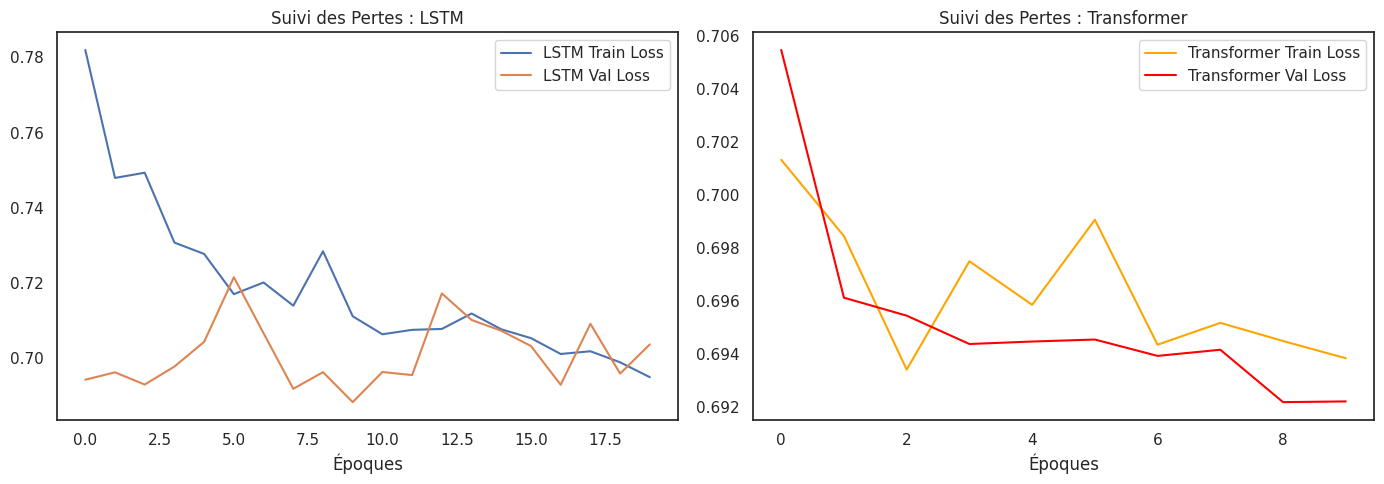

In [5]:
print("\n--- [5/6] Génération des courbes d'apprentissage ---")
plt.figure(figsize=(14, 5))

# Graphique Perte LSTM
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['loss'], label='LSTM Train Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM Val Loss')
plt.title('Suivi des Pertes : LSTM')
plt.xlabel('Époques')
plt.legend()

# Graphique Perte Transformer
plt.subplot(1, 2, 2)
plt.plot(history_transformer.history['loss'], label='Transformer Train Loss', color='orange')
plt.plot(history_transformer.history['val_loss'], label='Transformer Val Loss', color='red')
plt.title('Suivi des Pertes : Transformer')
plt.xlabel('Époques')
plt.legend()

plt.tight_layout()
plt.show()

# 6. ÉVALUATION CRITIQUE ET MATRICES DE CONFUSION


--- [6/6] Évaluation finale sur les données de Test ---
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step

RAPPORT PERFORMANCE : LSTM
Accuracy globale : 0.5185
              precision    recall  f1-score   support

  Baisse (0)       0.52      0.58      0.55       203
  Hausse (1)       0.52      0.46      0.49       202

    accuracy                           0.52       405
   macro avg       0.52      0.52      0.52       405
weighted avg       0.52      0.52      0.52       405


RAPPORT PERFORMANCE : TRANSFORMER
Accuracy globale : 0.5086
              precision    recall  f1-score   support

  Baisse (0)       0.51      0.99      0.67       203
  Hausse (1)       0.67      0.03      0.06       202

    accuracy                           0.51       405
   macro avg       0.59      0.51      0.36       405
weighted avg       0.59      0.51      0.36       405



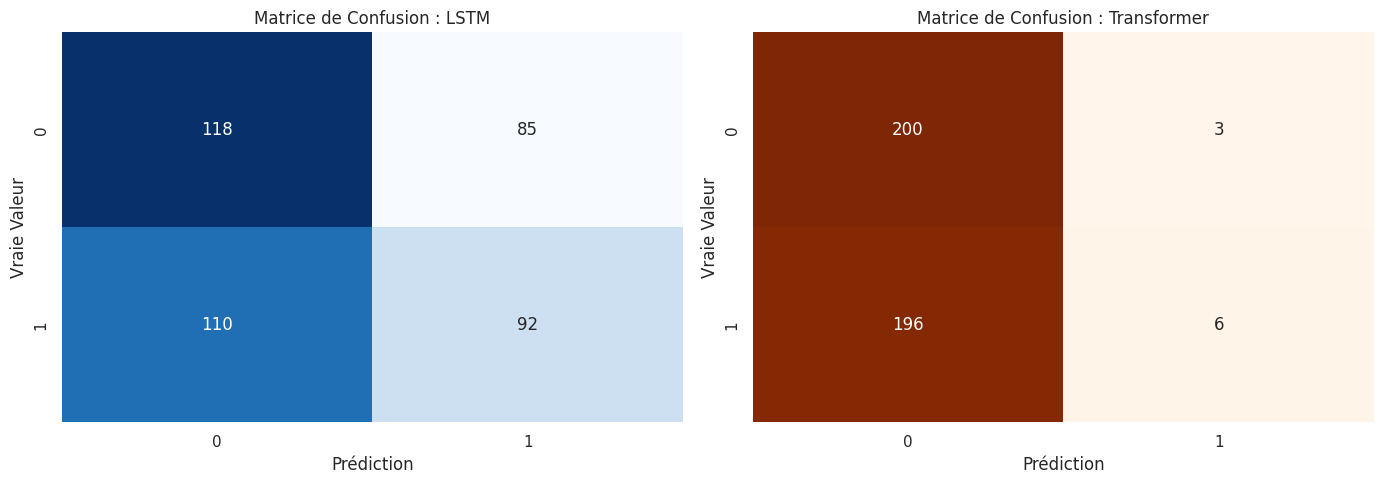

In [6]:
print("\n--- [6/6] Évaluation finale sur les données de Test ---")

# Prédictions
y_pred_lstm = (model_lstm.predict(X_test) > 0.5).astype(int)
y_pred_trans = (model_transformer.predict(X_test) > 0.5).astype(int)

# --- Affichage textuel ---
print("\n" + "="*60 + "\nRAPPORT PERFORMANCE : LSTM\n" + "="*60)
print(f"Accuracy globale : {accuracy_score(y_test, y_pred_lstm):.4f}")
print(classification_report(y_test, y_pred_lstm, target_names=['Baisse (0)', 'Hausse (1)']))

print("\n" + "="*60 + "\nRAPPORT PERFORMANCE : TRANSFORMER\n" + "="*60)
print(f"Accuracy globale : {accuracy_score(y_test, y_pred_trans):.4f}")
print(classification_report(y_test, y_pred_trans, target_names=['Baisse (0)', 'Hausse (1)']))

# --- Affichage graphique des matrices de confusion ---
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
cm_trans = confusion_matrix(y_test, y_pred_trans)

sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', ax=ax[0], cbar=False)
ax[0].set_title('Matrice de Confusion : LSTM')
ax[0].set_ylabel('Vraie Valeur')
ax[0].set_xlabel('Prédiction')

sns.heatmap(cm_trans, annot=True, fmt='d', cmap='Oranges', ax=ax[1], cbar=False)
ax[1].set_title('Matrice de Confusion : Transformer')
ax[1].set_ylabel('Vraie Valeur')
ax[1].set_xlabel('Prédiction')

plt.tight_layout()
plt.show()

# 7. Sauvegarde automatique du meilleur modèle

In [7]:
model_lstm.save("modele_trading_lstm.h5")
print("\n[OK] Fichier 'modele_trading_lstm.h5' enregistré ")


[OK] Fichier 'modele_trading_lstm.h5' enregistré 
